# Urban Green Score Project

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

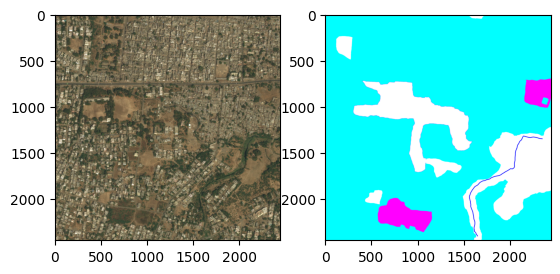

In [13]:
IMG_NUMBER = '2774'
IMG_DIR = 'train'

path_sat = IMG_DIR+'/'+IMG_NUMBER+'_sat.jpg'
path_mask = IMG_DIR+'/'+IMG_NUMBER+'_mask.png'

img_sat = np.asarray(Image.open(path_sat))
img_mask = np.asarray(Image.open(path_mask))

fig, axs = plt.subplots(1, 2)
axs[0].imshow(img_sat)
axs[1].imshow(img_mask)


In [25]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

IMG_DIR = 'train'

# récupérer tous les fichiers _sat.jpg
sat_images = [f for f in os.listdir(IMG_DIR) if f.endswith('_sat.jpg')]

# choisir 10 images aléatoires
sample_images = random.sample(sat_images, 10)
print(sample_images)

fig, axs = plt.subplots(10, 2, figsize=(10, 30))

for i, img_name in enumerate(sample_images):
    img_id = img_name.replace('_sat.jpg', '')
    
    path_sat = os.path.join(IMG_DIR, img_id + '_sat.jpg')
    path_mask = os.path.join(IMG_DIR, img_id + '_mask.png')
    
    img_sat = np.asarray(Image.open(path_sat))
    img_mask = np.asarray(Image.open(path_mask))
    
    axs[i, 0].imshow(img_sat)
    axs[i, 0].set_title(f"{img_id} - Satellite")
    axs[i, 0].axis('off')
    
    axs[i, 1].imshow(img_mask)
    axs[i, 1].set_title(f"{img_id} - Mask")
    axs[i, 1].axis('off')

plt.tight_layout()
plt.show()

['866782_sat.jpg', '847604_sat.jpg', '644150_sat.jpg', '686781_sat.jpg', '784518_sat.jpg', '978039_sat.jpg', '172307_sat.jpg', '142766_sat.jpg', '561117_sat.jpg', '195769_sat.jpg']


KeyboardInterrupt: 

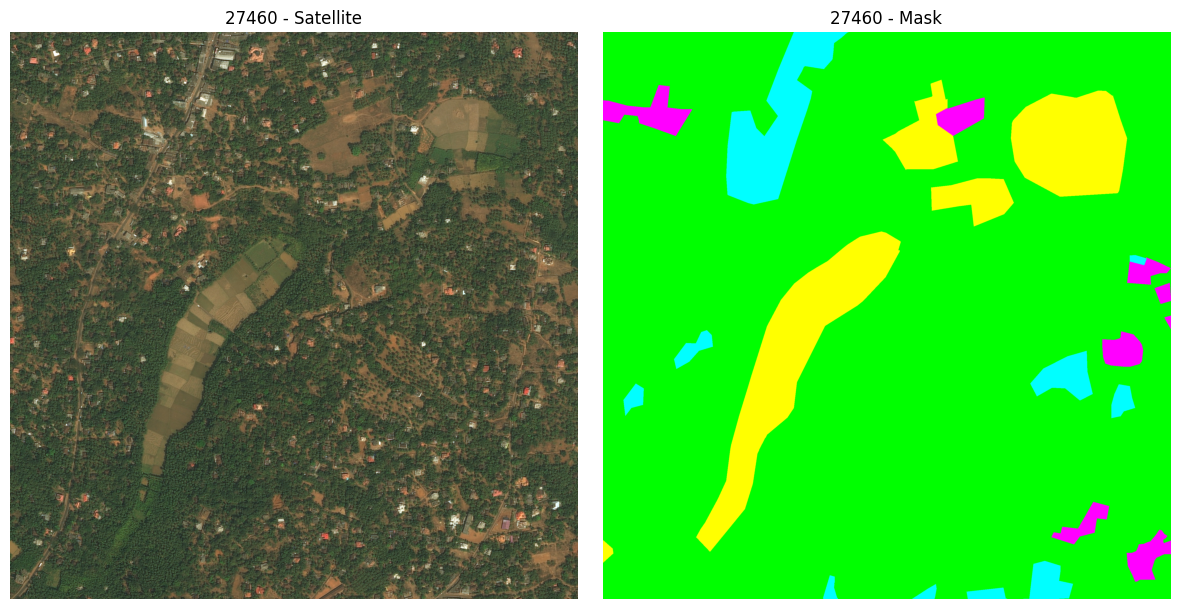


Class proportions:

urban_land: 0.0433 (4.33%)
agriculture_land: 0.0960 (9.60%)
rangeland: 0.0221 (2.21%)
forest_land: 0.8386 (83.86%)
water: 0.0000 (0.00%)
barren_land: 0.0000 (0.00%)


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

IMG_DIR = 'train'

# mapping classes → couleurs
CLASSES = {
    "urban_land": [0, 255, 255],       # cyan → zones urbaines (bâtiments, routes)
    "agriculture_land": [255, 255, 0], # jaune → zones agricoles (cultures)
    "rangeland": [255, 0, 255],        # violet → prairies / végétation basse
    "forest_land": [0, 255, 0],        # vert → forêts / végétation dense
    "water": [0, 0, 255],              # bleu → eau (rivières, lacs)
    "barren_land": [255, 255, 255],    # blanc → sol nu (sable, roche)
    "unknown": [0, 0, 0]               # noir → zones inconnues / non labellisées
}

# récupérer tous les masks
mask_images = [f for f in os.listdir(IMG_DIR) if f.endswith('_mask.png')]

# choisir une image aléatoire
img_name = random.choice(mask_images)
img_id = img_name.replace('_mask.png', '')

# chemins
path_mask = os.path.join(IMG_DIR, img_id + '_mask.png')
path_sat = os.path.join(IMG_DIR, img_id + '_sat.jpg')

# charger images
img_mask = np.asarray(Image.open(path_mask))
img_sat = np.asarray(Image.open(path_sat))

# affichage côte à côte
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(img_sat)
axs[0].set_title(f"{img_id} - Satellite")
axs[0].axis('off')

axs[1].imshow(img_mask)
axs[1].set_title(f"{img_id} - Mask")
axs[1].axis('off')

plt.tight_layout()
plt.show()

# calcul proportions
H, W, _ = img_mask.shape
total_pixels = H * W

print("\nClass proportions:\n")

for class_name, color in CLASSES.items():
    class_mask = np.all(img_mask == color, axis=-1)
    count = np.sum(class_mask)
    ratio = count / total_pixels
    
    print(f"{class_name}: {ratio:.4f} ({ratio*100:.2f}%)")